# 03 — Modeling + SHAP

Мета: навчити базову модель, оцінити метрики і пояснити результати через SHAP.

In [15]:
import pandas as pd
import numpy as np
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import f1_score, classification_report
import warnings
warnings.filterwarnings('ignore')

train = pd.read_csv('../data/processed/train_features.csv')

# Перевірка
print(train.shape)
print(train['is_fraud'].value_counts())
print(f"Fraud rate: {train['is_fraud'].mean():.3%}")
print(train.isnull().sum())  # перевірка на пропуски

(395381, 24)
is_fraud
0    380449
1     14932
Name: count, dtype: int64
Fraud rate: 3.777%
id_user                    0
is_fraud                   0
is_instant_registration    0
has_night_tx               0
is_country_mismatch        0
is_pay_mismatch            0
is_high_fraud_country      0
total_transactions         0
total_unique_cards         0
success_rate               0
failed_tx_count            0
has_fraud_error            0
has_name_email_match       0
max_amount                 0
std_amount                 0
unique_holders             0
unique_pay_countries       0
card_init_rate             0
failed_card_init_rate      0
cards_per_holder           0
holder_change_rate         0
traffic_type_enc           0
reg_country_enc            0
email_domain_enc           0
dtype: int64


In [16]:
TARGET = "is_fraud"
DROP_COLS = ["id_user", TARGET]

X = train.drop(columns=DROP_COLS)
y = train[TARGET]

print(f"Фічі: {X.columns.tolist()}")
print(f"Розмір X: {X.shape}")

Фічі: ['is_instant_registration', 'has_night_tx', 'is_country_mismatch', 'is_pay_mismatch', 'is_high_fraud_country', 'total_transactions', 'total_unique_cards', 'success_rate', 'failed_tx_count', 'has_fraud_error', 'has_name_email_match', 'max_amount', 'std_amount', 'unique_holders', 'unique_pay_countries', 'card_init_rate', 'failed_card_init_rate', 'cards_per_holder', 'holder_change_rate', 'traffic_type_enc', 'reg_country_enc', 'email_domain_enc']
Розмір X: (395381, 22)


In [17]:
import lightgbm as lgb

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
models = []
f1_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    m = lgb.LGBMClassifier(
        n_estimators=1128,
        learning_rate=0.010074431455595244,
        num_leaves=127,
        min_child_samples=36,
        max_depth=7,
        subsample=0.8148585414087771,
        colsample_bytree=0.691234580142291,
        reg_alpha=0.026795112742686374,
        reg_lambda=0.032104120677429036,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
    
    m.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )
    
    proba_val = m.predict_proba(X_val)[:, 1]
    
    best_f1, best_t = 0, 0.5
    for t in np.arange(0.05, 0.95, 0.01):
        preds = (proba_val >= t).astype(int)
        f1 = f1_score(y_val, preds, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_t = t
    
    f1_scores.append(best_f1)
    models.append(m)
    print(f"Fold {fold+1}: F1={best_f1:.4f}, threshold={best_t:.2f}")

print(f"\nСередній F1: {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")

Fold 1: F1=0.5826, threshold=0.89
Fold 2: F1=0.5797, threshold=0.90
Fold 3: F1=0.5839, threshold=0.90
Fold 4: F1=0.5721, threshold=0.90
Fold 5: F1=0.5807, threshold=0.89

Середній F1: 0.5798 ± 0.0041


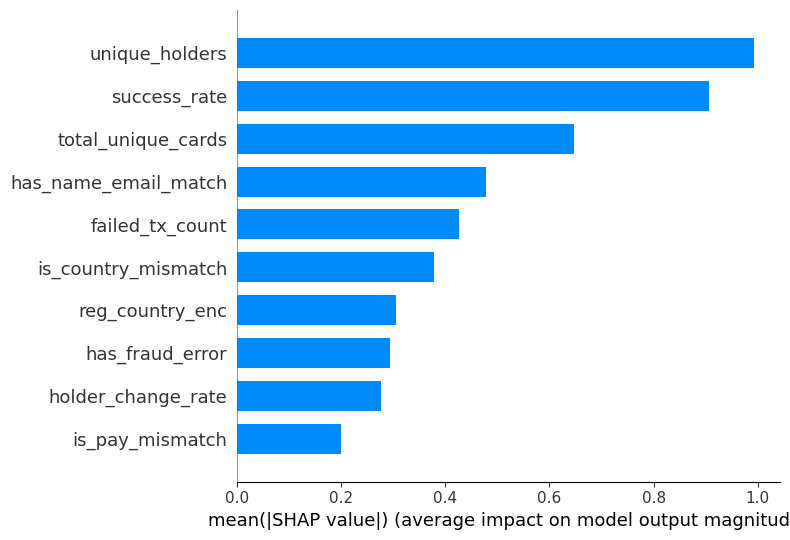

In [18]:
import shap
explainer = shap.TreeExplainer(models[-1])  # беремо останню модель
shap_values = explainer.shap_values(X.iloc[:1000])

if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

shap.summary_plot(sv, X.iloc[:1000], plot_type="bar", max_display=10)

In [20]:
test = pd.read_csv('../data/processed/test_features.csv')
X_test = test.drop(columns=["id_user"])

# Ensemble з 5 моделей — усереднюємо ймовірності
proba_test = np.mean([m.predict_proba(X_test)[:, 1] for m in models], axis=0)

# Середній threshold з крос-валідації
best_threshold = 0.89

test["is_fraud"] = (proba_test >= best_threshold).astype(int)
result = test[["id_user", "is_fraud"]]
result.to_csv('../outputs/predictions.csv', index=False)

print(result["is_fraud"].value_counts())
print("✅ Готово!")

is_fraud
0    162596
1      6853
Name: count, dtype: int64
✅ Готово!
